In [36]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent
RAW_PQ = ROOT / "data" / "raw" / "pq"
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "report" / "figures"
PROC.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 42
VAL_FRAC = 0.15

pd.set_option("display.max_columns", 100)
sns.set_theme(context="notebook", style="whitegrid")

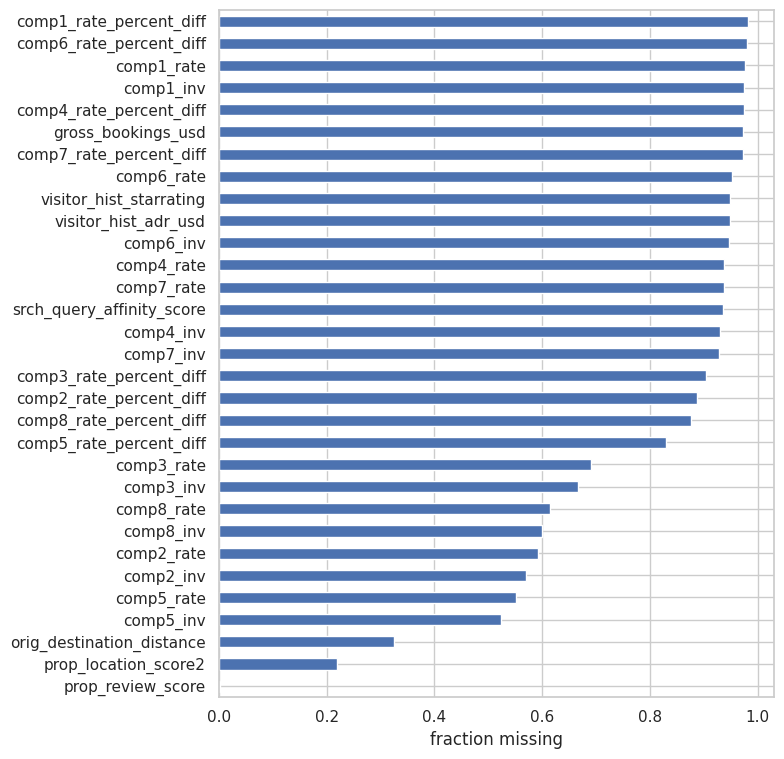

In [37]:
miss = (
    pd.read_parquet(RAW_PQ / "train.parquet", columns=None)
    .isna()
    .mean()
    .sort_values(ascending=False)
)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(miss))))
miss.plot.barh(ax=ax)
ax.set_xlabel("fraction missing")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG_DIR / "missingness.pdf", bbox_inches="tight")
plt.show()
del miss

In [38]:
COMP_RATE = [f"comp{i}_rate" for i in range(1, 9)]
COMP_INV = [f"comp{i}_inv" for i in range(1, 9)]
COMP_DIFF = [f"comp{i}_rate_percent_diff" for i in range(1, 9)]

PROP_SMOOTH_ALPHA = 10.0
DEST_SMOOTH_ALPHA = 50.0


def add_missing_flags(df):
    """Add binary flags indicating missing values for selected columns"""
    for c in [
        "prop_review_score",
        "prop_location_score2",
        "srch_query_affinity_score",
        "orig_destination_distance",
    ]:
        df[f"{c}_isnull"] = df[c].isna().astype("uint8")


def add_datetime_features(df):
    """Extract datetime features from the 'date_time' column"""
    dt = df["date_time"]
    df["month"] = dt.dt.month.astype("uint8")
    df["dow"] = dt.dt.dayofweek.astype("uint8")
    df["hour"] = dt.dt.hour.astype("uint8")
    df["is_weekend"] = (dt.dt.dayofweek >= 5).astype("uint8")


def add_price_features(df):
    """Add 7 price-related features"""
    df["price_usd_clipped"] = df["price_usd"].clip(upper=5000.0).astype("float32")
    df["log_price"] = np.log1p(df["price_usd_clipped"]).astype("float32")
    df["price_per_night"] = (
        df["price_usd_clipped"] / df["srch_length_of_stay"].clip(lower=1)
    ).astype("float32")
    pax = (
        df["srch_adults_count"].astype("float32") + df["srch_children_count"].astype("float32")
    ).clip(lower=1)
    df["price_per_person"] = (df["price_usd_clipped"] / pax).astype("float32")

    grp = df.groupby("srch_id")["price_usd_clipped"]
    df["price_rank_in_query"] = grp.rank(method="average").astype("float32")
    query_mean = grp.transform("mean")
    df["price_rel_to_query_mean"] = (
        df["price_usd_clipped"] / query_mean.replace(0, np.nan)
    ).astype("float32")
    del query_mean

    df["price_vs_prop_hist"] = (df["log_price"] - df["prop_log_historical_price"]).astype(
        "float32"
    )


def add_rank_features(df):
    """Add rank-based features for properties within each search query"""
    grp = df.groupby("srch_id")
    df["star_rank_in_query"] = (
        grp["prop_starrating"].rank(method="average", ascending=False).astype("float32")
    )
    df["review_rank_in_query"] = (
        grp["prop_review_score"].rank(method="average", ascending=False).astype("float32")
    )
    df["loc1_rank_in_query"] = (
        grp["prop_location_score1"].rank(method="average", ascending=False).astype("float32")
    )
    df["loc2_rank_in_query"] = (
        grp["prop_location_score2"].rank(method="average", ascending=False).astype("float32")
    )


def add_competitor_features(df):
    """Add features related to competitors' rates, availability, and price differences"""
    rate = df[COMP_RATE].to_numpy(dtype="float32")
    inv = df[COMP_INV].to_numpy(dtype="float32")
    diff = df[COMP_DIFF].to_numpy(dtype="float32")

    df["comp_rate_n"] = (~np.isnan(rate)).sum(axis=1).astype("uint8")
    df["comp_rate_sum"] = np.nansum(rate, axis=1).astype("float32")
    df["comp_inv_sum"] = np.nansum(inv, axis=1).astype("float32")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        diff_mean = np.nanmean(np.abs(diff), axis=1)
    df["comp_diff_mean"] = np.nan_to_num(diff_mean, nan=0.0).astype("float32")
    del rate, inv, diff, diff_mean


def add_visitor_history_features(df):
    """Add features related to the visitor's historical interactions with properties"""
    df["visitor_has_history"] = (~df["visitor_hist_starrating"].isna()).astype("uint8")
    df["star_diff_vs_visitor_hist"] = (
        df["prop_starrating"] - df["visitor_hist_starrating"]
    ).astype("float32")
    df["price_diff_vs_visitor_hist"] = (
        df["price_usd_clipped"] - df["visitor_hist_adr_usd"]
    ).astype("float32")
    for c in [
        "visitor_hist_starrating",
        "visitor_hist_adr_usd",
        "star_diff_vs_visitor_hist",
        "price_diff_vs_visitor_hist",
    ]:
        df[c] = df[c].fillna(0).astype("float32")


def smoothed_rate(positives, n, global_rate, alpha):
    """Calculate a Bayesian-smoothed rate given the number of positives, total
    count, global rate, and smoothing parameter alpha.
    """
    return ((positives + alpha * global_rate) / (n + alpha)).astype("float32")


def build_property_stats(train_df, global_ctr, global_cvr, alpha=PROP_SMOOTH_ALPHA):
    """Per-prop_id smoothed CTR (clicks/impressions) and CVR (bookings/clicks),
    plus position and price stats. CTR/CVR follow Liu et al. (2013) Eqs. 2-3.
    """
    g = train_df.groupby("prop_id")
    n = g.size().astype("uint32")
    clicks = g["click_bool"].sum()
    books = g["booking_bool"].sum()
    return pd.DataFrame(
        {
            "prop_click_rate": smoothed_rate(clicks, n, global_ctr, alpha),
            "prop_book_rate": smoothed_rate(books, clicks, global_cvr, alpha),
            "prop_mean_position": g["position"].mean().astype("float32"),
            "prop_median_price": g["price_usd"].median().astype("float32"),
            "prop_n_impressions": n,
        }
    ).reset_index()


def build_dest_stats(train_df, global_ctr, global_cvr, alpha=DEST_SMOOTH_ALPHA):
    """Per-srch_destination_id smoothed CTR and CVR plus median price."""
    g = train_df.groupby("srch_destination_id")
    n = g.size().astype("uint32")
    clicks = g["click_bool"].sum()
    books = g["booking_bool"].sum()
    return pd.DataFrame(
        {
            "dest_click_rate": smoothed_rate(clicks, n, global_ctr, alpha),
            "dest_book_rate": smoothed_rate(books, clicks, global_cvr, alpha),
            "dest_median_price": g["price_usd"].median().astype("float32"),
        }
    ).reset_index()

In [39]:
raw = pd.read_parquet(RAW_PQ / "train.parquet")

rng = np.random.default_rng(RNG_SEED)
all_srch = raw["srch_id"].unique()
rng.shuffle(all_srch)
n_val = int(len(all_srch) * VAL_FRAC)
val_ids = pd.Index(all_srch[:n_val])
is_val = raw["srch_id"].isin(val_ids)

raw.loc[is_val].reset_index(drop=True).to_parquet(
    PROC / "_tmp_val_raw.parquet", compression="snappy", index=False
)

train_raw = raw.loc[~is_val].reset_index(drop=True)
del raw, is_val, all_srch, val_ids
print(f"train_raw: {train_raw.shape[0]:,} rows, {train_raw['srch_id'].nunique():,} searches")

train_raw: 4,215,569 rows, 169,826 searches


In [40]:
GLOBAL_CTR = float(train_raw["click_bool"].mean())
GLOBAL_CVR = float(train_raw["booking_bool"].sum() / train_raw["click_bool"].sum())
GLOBAL_POS = float(train_raw["position"].median())
GLOBAL_PRICE_MED = float(train_raw["price_usd"].median())

prop_stats = build_property_stats(train_raw, GLOBAL_CTR, GLOBAL_CVR)
dest_stats = build_dest_stats(train_raw, GLOBAL_CTR, GLOBAL_CVR)

median_fills = {
    "prop_review_score": float(train_raw["prop_review_score"].median()),
    "prop_location_score2": float(train_raw["prop_location_score2"].median()),
    "srch_query_affinity_score": float(train_raw["srch_query_affinity_score"].median()),
    "orig_destination_distance": float(train_raw["orig_destination_distance"].median()),
}

print("median fills:", median_fills)
print(f"global CTR (clicks/impressions): {GLOBAL_CTR:.4f}")
print(f"global CVR (bookings/clicks):    {GLOBAL_CVR:.4f}")
print(f"prop_stats:  {len(prop_stats):,} unique prop_ids (alpha={PROP_SMOOTH_ALPHA})")
print(f"dest_stats:  {len(dest_stats):,} unique destinations (alpha={DEST_SMOOTH_ALPHA})\n")
print("prop_click_rate distribution (smoothed CTR):")
print(prop_stats["prop_click_rate"].describe(percentiles=[0.01, 0.5, 0.99]).to_string())
print("\nprop_book_rate distribution (smoothed CVR):")
print(prop_stats["prop_book_rate"].describe(percentiles=[0.01, 0.5, 0.99]).to_string())

median fills: {'prop_review_score': 4.0, 'prop_location_score2': 0.06889999657869339, 'srch_query_affinity_score': -20.4424991607666, 'orig_destination_distance': 386.760009765625}
global CTR (clicks/impressions): 0.0447
global CVR (bookings/clicks):    0.6239
prop_stats:  127,158 unique prop_ids (alpha=10.0)
dest_stats:  16,936 unique destinations (alpha=50.0)

prop_click_rate distribution (smoothed CTR):
count    127158.000000
mean          0.045852
std           0.035645
min           0.001017
1%            0.005965
50%           0.037112
99%           0.176416
max           0.520336

prop_book_rate distribution (smoothed CVR):
count    127158.000000
mean          0.622822
std           0.043512
min           0.228865
1%            0.479933
50%           0.623912
99%           0.749275
max           0.921648


In [41]:
def transform(df, *, is_train):
    """Apply all feature engineering transformations to the input DataFrame."""
    add_missing_flags(df)
    for col, val in median_fills.items():
        df[col] = df[col].fillna(val).astype("float32")

    add_datetime_features(df)
    add_price_features(df)
    add_rank_features(df)
    add_competitor_features(df)
    add_visitor_history_features(df)

    df = df.merge(prop_stats, on="prop_id", how="left")
    df = df.merge(dest_stats, on="srch_destination_id", how="left")

    df["prop_click_rate"] = df["prop_click_rate"].fillna(GLOBAL_CTR).astype("float32")
    df["prop_book_rate"] = df["prop_book_rate"].fillna(GLOBAL_CVR).astype("float32")
    df["prop_mean_position"] = df["prop_mean_position"].fillna(GLOBAL_POS).astype("float32")
    df["prop_median_price"] = df["prop_median_price"].fillna(GLOBAL_PRICE_MED).astype("float32")
    df["prop_n_impressions"] = df["prop_n_impressions"].fillna(0).astype("uint32")
    df["dest_click_rate"] = df["dest_click_rate"].fillna(GLOBAL_CTR).astype("float32")
    df["dest_book_rate"] = df["dest_book_rate"].fillna(GLOBAL_CVR).astype("float32")
    df["dest_median_price"] = df["dest_median_price"].fillna(GLOBAL_PRICE_MED).astype("float32")

    if is_train:

        df["relevance"] = np.where(
            df["booking_bool"] == 1,
            5,
            np.where(df["click_bool"] == 1, 1, 0),
        ).astype("int8")

    df = df.drop(columns=COMP_RATE + COMP_INV + COMP_DIFF)
    return df

In [42]:
train_fe = transform(train_raw, is_train=True)
del train_raw
print(f"train_fe: {train_fe.shape}")
print("NaNs remaining:", int(train_fe.isna().sum().sum()))
train_fe.to_parquet(PROC / "train.parquet", compression="snappy", index=False)
print(f"  -> wrote {(PROC / 'train.parquet').stat().st_size / (1 << 20):.1f} MB")
del train_fe

train_fe: (4215569, 65)
NaNs remaining: 4097901
  -> wrote 193.1 MB


In [43]:
val_raw = pd.read_parquet(PROC / "_tmp_val_raw.parquet")
val_fe = transform(val_raw, is_train=True)
del val_raw
print(f"val_fe: {val_fe.shape}")
val_fe.to_parquet(PROC / "val.parquet", compression="snappy", index=False)
print(f"  -> wrote {(PROC / 'val.parquet').stat().st_size / (1 << 20):.1f} MB")
del val_fe
(PROC / "_tmp_val_raw.parquet").unlink()

val_fe: (742778, 65)
  -> wrote 34.4 MB


In [44]:
test_raw = pd.read_parquet(RAW_PQ / "test.parquet")
test_fe = transform(test_raw, is_train=False)
del test_raw
print(f"test_fe: {test_fe.shape}")
test_fe.to_parquet(PROC / "test.parquet", compression="snappy", index=False)
print(f"  -> wrote {(PROC / 'test.parquet').stat().st_size / (1 << 20):.1f} MB")
del test_fe

test_fe: (4959183, 60)
  -> wrote 221.4 MB


relevance
0    4026972
1      70929
5     117668
Name: count, dtype: int64


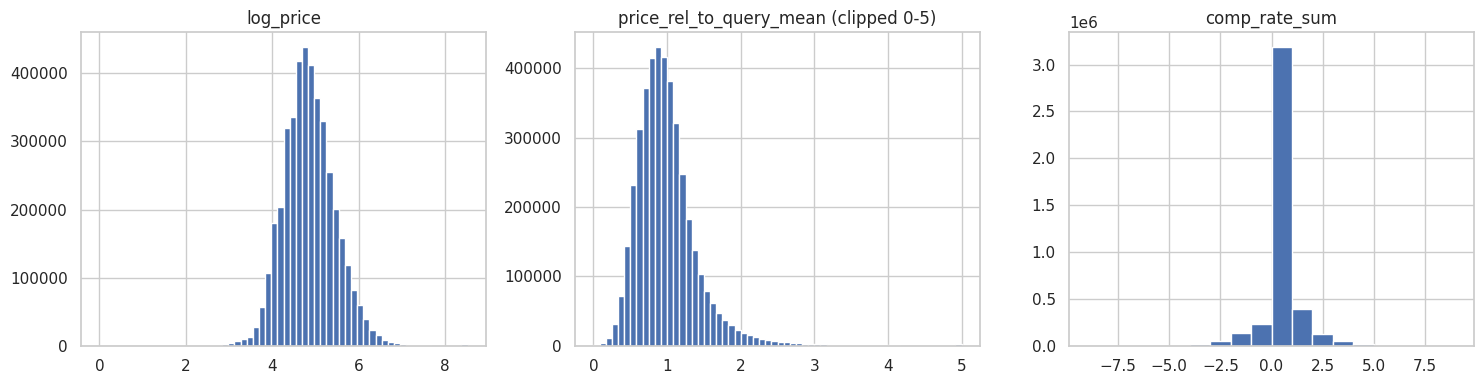

In [45]:
check = pd.read_parquet(
    PROC / "train.parquet",
    columns=["log_price", "price_rel_to_query_mean", "comp_rate_sum",
             "position", "click_bool", "relevance"],
)
print(check["relevance"].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(check["log_price"], bins=60)
axes[0].set_title("log_price")
axes[1].hist(check["price_rel_to_query_mean"].clip(0, 5), bins=60)
axes[1].set_title("price_rel_to_query_mean (clipped 0-5)")
axes[2].hist(check["comp_rate_sum"], bins=range(-9, 10))
axes[2].set_title("comp_rate_sum")
plt.tight_layout()
fig.savefig(FIG_DIR / "feature_histograms.pdf", bbox_inches="tight")
plt.show()

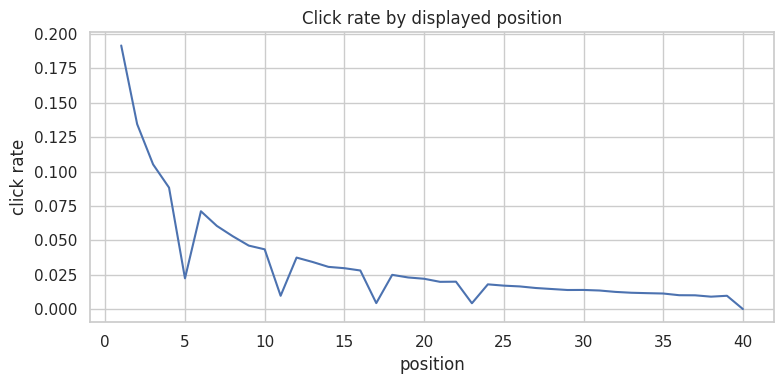

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
check.groupby("position")["click_bool"].mean().plot(ax=ax)
ax.set_title("Click rate by displayed position")
ax.set_ylabel("click rate")
plt.tight_layout()
fig.savefig(FIG_DIR / "position_bias.pdf", bbox_inches="tight")
plt.show()
del check

In [47]:
for name in ("train", "val", "test"):
    p = PROC / f"{name}.parquet"
    if p.exists():
        df = pd.read_parquet(p, columns=["srch_id"])
        print(f"{name}: {p.stat().st_size / (1 << 20):>6.1f} MB  |  {len(df):>9,} rows  |  {df['srch_id'].nunique():>7,} searches")
        del df

train:  193.1 MB  |  4,215,569 rows  |  169,826 searches
val:   34.4 MB  |    742,778 rows  |   29,969 searches
test:  221.4 MB  |  4,959,183 rows  |  199,549 searches
